<h1 style="color:yellow">Lung Cancer Disease Prediction</h1>

<p style="font-size:18px; line-height:1.5;">
    This project uses medical image analysis and machine learning to predict the likelihood of lung cancer 
    based on the <strong>Lung Image Database Consortium (LIDC)</strong> dataset. The LIDC dataset contains 
    high-resolution CT scans of the chest, annotated by expert radiologists for the presence, location, 
    and characteristics of lung nodules — including their size, shape, and malignancy.
</p>

<p style="font-size:18px; line-height:1.5;">
    By extracting quantitative features from these nodules (such as texture, calcification, spiculation, 
    and lobulation), this prediction system trains a classification model to distinguish benign nodules 
    from malignant ones. The ultimate goal is to assist clinicians in early lung cancer detection, 
    potentially improving patient outcomes through timely intervention.
</p>

<p style="font-size:18px; line-height:1.5;">
    <strong>Key steps in this project:</strong>
    <ul style="font-size:18px; line-height:1.5;">
        <li>Preprocessing CT images from the LIDC dataset (e.g., resampling, normalization).</li>
        <li>Segmentation or identification of regions of interest (lung nodules).</li>
        <li>Feature extraction (radiomics) and selection.</li>
        <li>Training and validation of a classifier (e.g., SVM, Random Forest, or CNN).</li>
        <li>Evaluation using metrics like accuracy, sensitivity, and AUC.</li>
    </ul>
</p>

> <p style="font-size:18px; line-height:1.5;">
    <em>Disclaimer: This tool is for research and educational purposes only. It is not a substitute for 
    professional medical diagnosis. Always consult a qualified healthcare provider for medical decisions.</em>
 </p>

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Import Modules

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

## Import  Datasets 

In [3]:
data_dir = "../data"

images = []
labels = []

for patient in os.listdir(data_dir):
    patient_path = os.path.join(data_dir, patient)

    if not os.path.isdir(patient_path):
        continue
        
    for nodule in os.listdir(patient_path):
        nodule_path = os.path.join(patient_path, nodule)
        img_path = os.path.join(nodule_path, "images")
        
        # label: nodule-0 = benign(0), nodule-1+ = malignant(1)
        label = 0 if nodule == "nodule-0" else 1
        
        for img_file in os.listdir(img_path):
            if img_file.endswith(".png"):
                img = Image.open(os.path.join(img_path, img_file)).convert("RGB")
                images.append(img)
                labels.append(label)

print(f"Total images: {len(images)}, Labels: {len(labels)}")

Total images: 15548, Labels: 15548


## Data Pre-processing 

In [4]:
class NoduleDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [5]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

train_ds = NoduleDataset(X_train, y_train, transform)
test_ds  = NoduleDataset(X_test,  y_test,  transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32)

print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

print(f"Train Batch: {len(train_loader)}, Test Batch: {len(test_loader)}")

Train: 12438, Test: 3110
Train Batch: 389, Test Batch: 98


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

cpu


## Model Training

In [7]:
train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(10):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(out, dim=1)
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)
    train_acc = correct / total * 100

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            val_loss += loss.item()
            preds = torch.argmax(out, dim=1)
            val_correct += (preds == lbls).sum().item()
            val_total += lbls.size(0)
    val_acc = val_correct / val_total * 100

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(total_loss / len(train_loader))
    val_loss_list.append(val_loss / len(test_loader))

    print(f"Epoch {epoch+1}/10 | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss/len(test_loader):.4f} | Val Acc: {val_acc:.2f}%")

Epoch 1/10 | Loss: 0.6467 | Train Acc: 67.53% | Val Loss: 0.5746 | Val Acc: 71.77%
Epoch 2/10 | Loss: 0.5109 | Train Acc: 75.99% | Val Loss: 0.4954 | Val Acc: 76.53%
Epoch 3/10 | Loss: 0.3747 | Train Acc: 83.86% | Val Loss: 0.4203 | Val Acc: 81.64%
Epoch 4/10 | Loss: 0.2615 | Train Acc: 89.73% | Val Loss: 0.3303 | Val Acc: 85.79%
Epoch 5/10 | Loss: 0.1671 | Train Acc: 93.66% | Val Loss: 0.1985 | Val Acc: 93.02%
Epoch 6/10 | Loss: 0.1057 | Train Acc: 96.16% | Val Loss: 0.1682 | Val Acc: 93.73%
Epoch 7/10 | Loss: 0.0847 | Train Acc: 97.09% | Val Loss: 0.1491 | Val Acc: 94.37%
Epoch 8/10 | Loss: 0.0645 | Train Acc: 97.65% | Val Loss: 0.1779 | Val Acc: 93.15%
Epoch 9/10 | Loss: 0.0504 | Train Acc: 98.06% | Val Loss: 0.1617 | Val Acc: 95.18%
Epoch 10/10 | Loss: 0.0455 | Train Acc: 98.54% | Val Loss: 0.1635 | Val Acc: 94.98%


## Model Efficiency

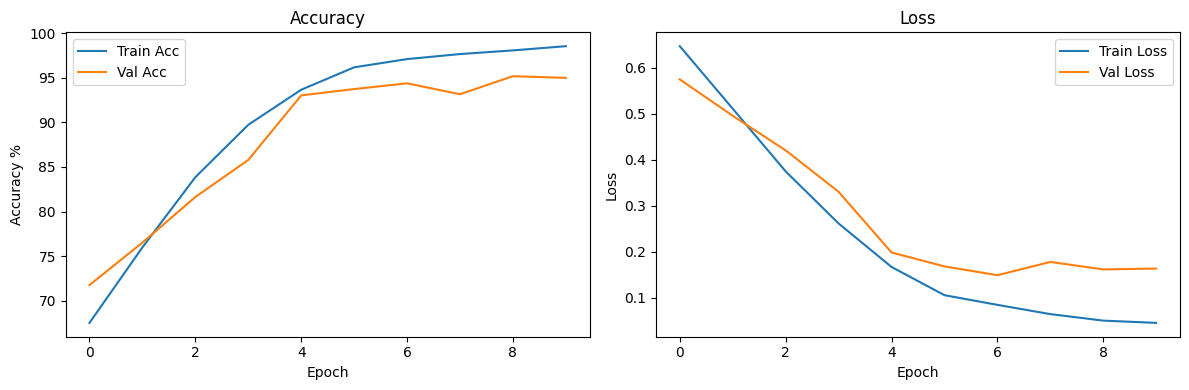

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label="Train Acc")
plt.plot(val_acc_list, label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Model Evaluation

In [9]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        preds = torch.argmax(out, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.93      0.94      0.93      1157
   Malignant       0.96      0.96      0.96      1953

    accuracy                           0.95      3110
   macro avg       0.95      0.95      0.95      3110
weighted avg       0.95      0.95      0.95      3110



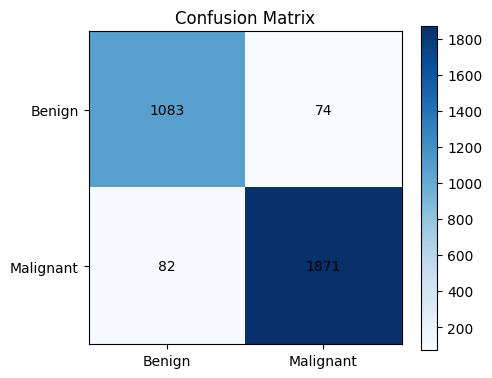

In [10]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["Benign", "Malignant"])
plt.yticks([0,1], ["Benign", "Malignant"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

## Model Save 

In [11]:
# Save model after training
model_path = "../models/resnet_lidc_model.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': ['benign', 'malignant']  # change if needed
}, model_path)

print(f"Model saved at {model_path}")

Model saved at ../models/resnet_lidc_model.pth


In [12]:
# Load model
model_path = "../models/resnet_lidc_model.pth"

checkpoint = torch.load(model_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

class_names = checkpoint['class_names']

print("Model loaded successfully")

Model loaded successfully
